In [22]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

import matplotlib.ticker as ticker

import matplotlib.cm as cm

from warnings import filterwarnings

filterwarnings('ignore')

In [23]:


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# generate viridis color palette
viridis_colors = cm.viridis(np.linspace(0, 1, 5))

primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]

custom_palette = viridis_colors

In [24]:
df=pd.read_csv("/content/DataCoSupplyChainDataset.csv",encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [25]:
df.shape

(180519, 53)

In [26]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# EDA

In [27]:
# Overview
print('rows, cols:', df.shape)

print('Columns:')
print(df.columns.tolist())

print('\nNum duplicates:', df.duplicated().sum())

print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)
Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product

In [28]:
# Data Cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

In [29]:
df=df.drop(columns=columns_to_drop)

In [30]:
df.shape

(180519, 20)

In [31]:
# Remove canceled orders (not useful for delivery analysis)
df = df[df['Delivery Status'] != 'Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# After cleaning, check dataset again
print('rows, cols:', df.shape)

print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [32]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [33]:
# calculating order processing time and delay
'''
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']'''
df['Delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']


df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month

df['order_day'] = df['order date (DateOrders)'].dt.day_name()

df['order_hour'] = df['order date (DateOrders)'].dt.hour

df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,0.565496,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.493242,3.405593,6.927276


In [34]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,98977
False,73788


In [35]:
df['Profitability Flag'] = np.select(
    [
        df['Order Profit Per Order'] > 0,
        df['Order Profit Per Order'] < 0
    ],
    [
        'Profit',
        'Loss'
    ],
    default='Breakeven'
)

df['Profitability Flag'].value_counts()

,count
Profitability Flag,
Profit,139354
Loss,32295
Breakeven,1116


In [36]:
df['Profitability Flag'].value_counts(normalize=True)

,proportion
Profitability Flag,
Profit,0.80661
Loss,0.18693
Breakeven,0.00646


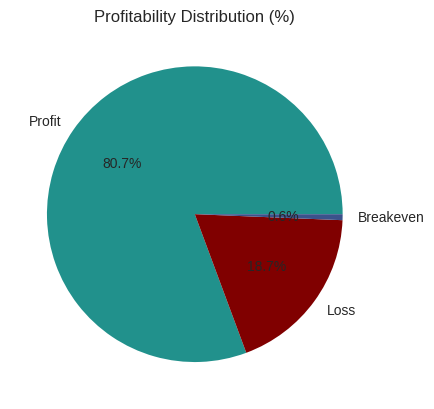

In [37]:
# visualization of profitability distribution

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [38]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


# Filter delayed orders
delayed_df = df[df['Delay'] > 0]

# Metrics dictionary
metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)

metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

metrics['On time Delivery %'] = (
    (1 - metrics['Late Deliveries'] / metrics['Total Orders']) * 100
)

metrics['Late Delivery %'] = (
    metrics['Late Deliveries'] / metrics['Total Orders'] * 100
)

metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)

metrics['Total Loss due to delays'] = format_func(
    df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
)

# Print KPIs
print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 98977
90% Delay (days): 3.00
On time Delivery %: 42.71
Late Delivery %: 57.29
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


# Profitability VS Delivery Analysis

In [39]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
      .agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count'
      )
      .reset_index()
)

profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.709146,7.311437e+05,32196
3,1,22.071211,1.279181e+06,57957
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [40]:
delay_distribution = (
    df['Delay']
      .value_counts(normalize=True)
      .sort_index() * 100
).reset_index()

delay_distribution.columns = ['Delay', 'Percentage']

delay_distribution

,Delay,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,18.635719
3,1,33.546725
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.7,731143.7,32196
3,1,22.1,1279181.2,57957
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697


Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,18.635719
3,1,33.546725
4,2,15.947096
5,3,3.919775
6,4,3.876364


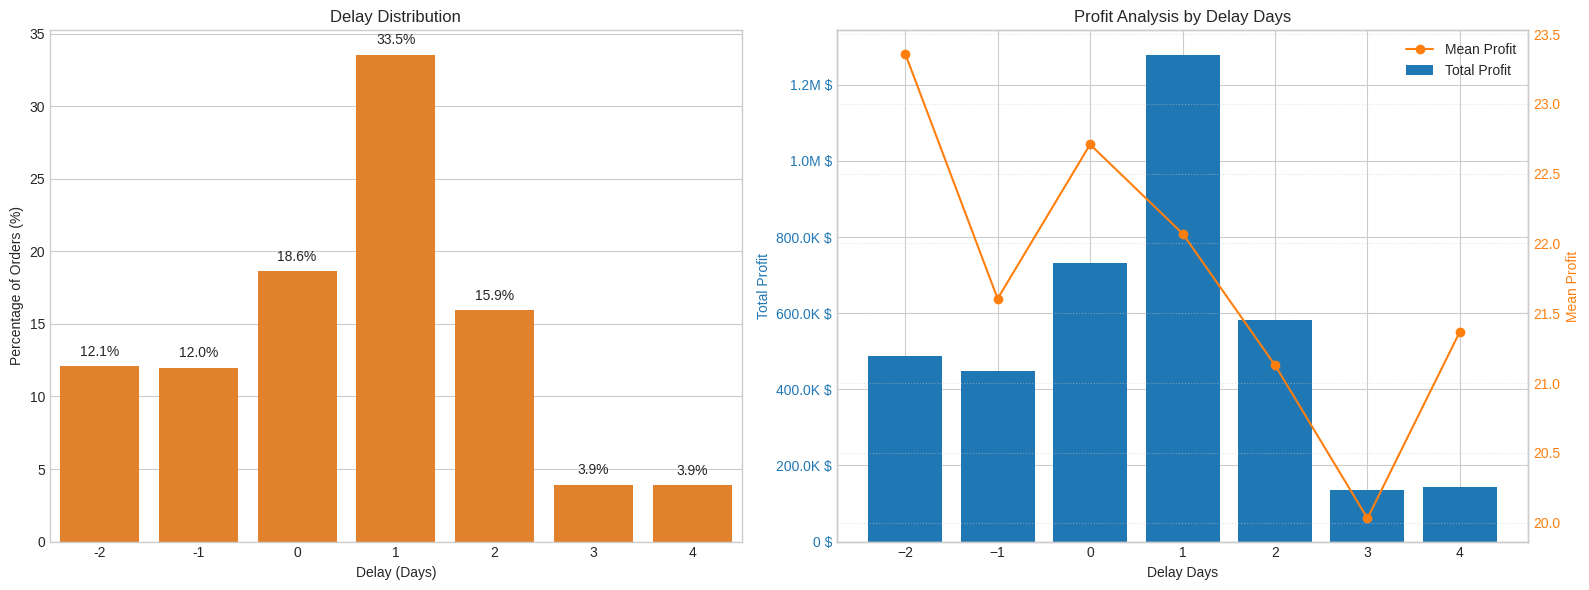

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

# Rename columns
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("Delay Distribution (%):")
display(delay_distribution)


# Colors
primary_color = "#1f77b4"
accent_color = "#ff7f0e"


# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


# -----------------------------
# 1. Delay Distribution
# -----------------------------
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title("Delay Distribution")
ax1.set_xlabel("Delay (Days)")
ax1.set_ylabel("Percentage of Orders (%)")


# Add percentage labels
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom'
    )


# -----------------------------
# 2. Profit Analysis
# -----------------------------

ax2.set_title("Profit Analysis by Delay Days")


# Total Profit Bar
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label="Total Profit"
)

ax2.set_xlabel("Delay Days")
ax2.set_ylabel("Total Profit", color=primary_color)

ax2.tick_params(
    axis='y',
    labelcolor=primary_color
)


# Mean Profit Line (Secondary Axis)
ax3 = ax2.twinx()

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    color=accent_color,
    label="Mean Profit"
)

ax3.set_ylabel(
    "Mean Profit",
    color=accent_color
)

ax3.tick_params(
    axis='y',
    labelcolor=accent_color
)


# Format money axis
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)


# Combine legends
lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax3.legend(
    lines + lines2,
    labels + labels2,
    loc='upper right'
)


ax3.grid(
    True,
    linestyle=':',
    alpha=0.5
)


plt.tight_layout()
plt.show()

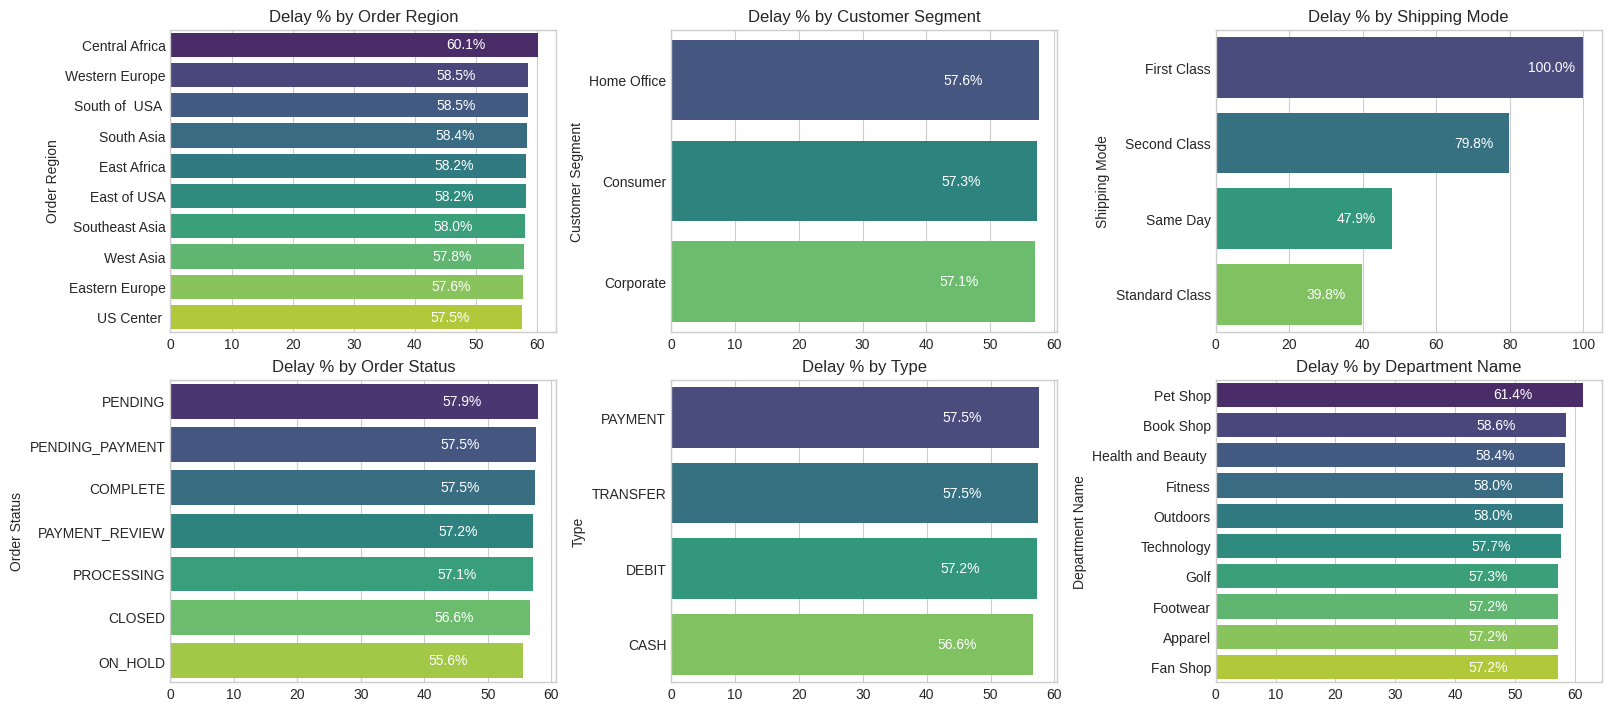

In [42]:
def compute_delay_pct_by_category(category):

    cat_df = (
        df.groupby(category)
        .agg(
            total_orders=('Delay', 'count'),
            late_orders=('Is_Delayed', 'sum')
        )
        .reset_index()
    )

    cat_df['delay_pct'] = (
        cat_df['late_orders'] / cat_df['total_orders'] * 100
    )

    cat_df = (
        cat_df
        .sort_values('delay_pct', ascending=False)
        .head(10)
    )

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]


fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()


for ax, category in zip(axes, categories):

    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)


    # Add percentage labels
    for i, row in cat_df.reset_index(drop=True).iterrows():

        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )


plt.show()

# TIME BASED ANALYSIS

In [43]:
# Delay % by Month

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_month['delay_pct'] = (
    delay_by_month['Is_Delayed'] * 100
)


# Delay % by Day of Week

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_day['delay_pct'] = (
    delay_by_day['Is_Delayed'] * 100
)


# Delay % by Hour

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_hour['delay_pct'] = (
    delay_by_hour['Is_Delayed'] * 100
)


# Display results

print("Delay % by Month")
display(delay_by_month)


print("Delay % by Day")
display(delay_by_day)


print("Delay % by Hour")
display(delay_by_hour)

Delay % by Month


,order_month,Is_Delayed,delay_pct
0,1,0.568396,56.839609
1,2,0.572481,57.248104
2,3,0.575165,57.516511
3,4,0.567039,56.703892
4,5,0.576619,57.661875
5,6,0.573125,57.312526
6,7,0.567370,56.736981
7,8,0.580072,58.007187
8,9,0.577623,57.762342
9,10,0.568204,56.820373


Delay % by Day


,order_day,Is_Delayed,delay_pct
0,Friday,0.574995,57.499497
1,Monday,0.578060,57.806010
2,Saturday,0.569161,56.916054
3,Sunday,0.575847,57.584666
4,Thursday,0.573180,57.318011
5,Tuesday,0.565914,56.591418
6,Wednesday,0.573117,57.311736


Delay % by Hour


,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


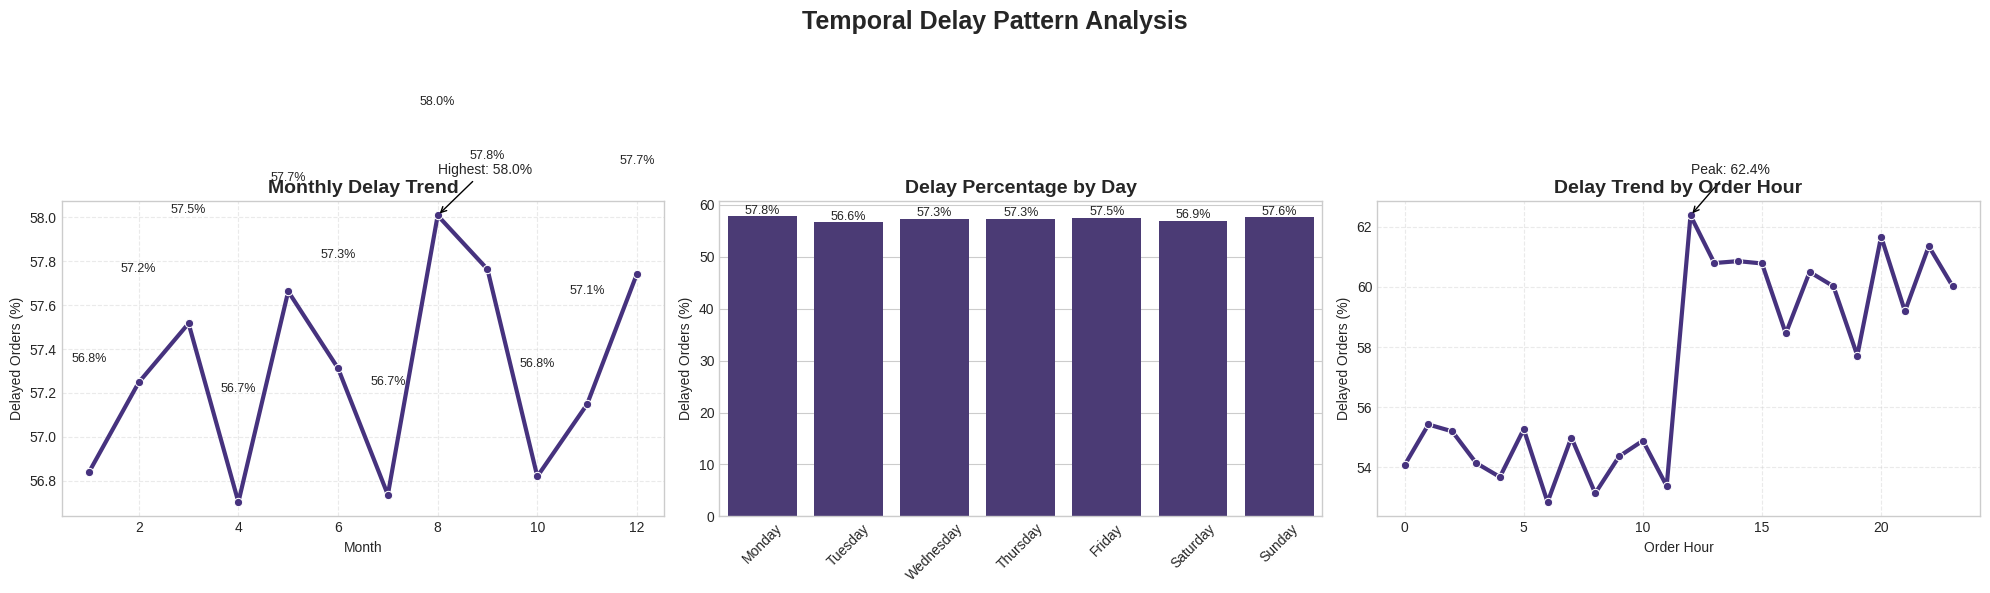

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# -----------------------------
# Prepare ordering
# -----------------------------

# Month ordering
if delay_by_month['order_month'].dtype != 'object':
    delay_by_month = delay_by_month.sort_values('order_month')


# Day ordering (if names exist)
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

if delay_by_day['order_day'].dtype == 'object':
    delay_by_day['order_day'] = pd.Categorical(
        delay_by_day['order_day'],
        categories=day_order,
        ordered=True
    )

    delay_by_day = delay_by_day.sort_values('order_day')


# Hour ordering
delay_by_hour = delay_by_hour.sort_values('order_hour')



# -----------------------------
# Plot
# -----------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20,6)
)


# =============================
# 1. MONTH ANALYSIS
# =============================

sns.lineplot(
    data=delay_by_month,
    x='order_month',
    y='delay_pct',
    marker='o',
    linewidth=3,
    ax=axes[0]
)


axes[0].set_title(
    "Monthly Delay Trend",
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel("Month")
axes[0].set_ylabel("Delayed Orders (%)")


axes[0].grid(
    linestyle='--',
    alpha=0.4
)


# labels + peak highlight

max_month = delay_by_month.loc[
    delay_by_month['delay_pct'].idxmax()
]


for x,y in zip(
    delay_by_month['order_month'],
    delay_by_month['delay_pct']
):

    axes[0].text(
        x,
        y+0.5,
        f"{y:.1f}%",
        ha='center',
        fontsize=9
    )


axes[0].annotate(
    f"Highest: {max_month['delay_pct']:.1f}%",
    xy=(
        max_month['order_month'],
        max_month['delay_pct']
    ),
    xytext=(0,30),
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->'
    )
)



# =============================
# 2. DAY ANALYSIS
# =============================


sns.barplot(
    data=delay_by_day,
    x='order_day',
    y='delay_pct',
    ax=axes[1]
)


axes[1].set_title(
    "Delay Percentage by Day",
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Delayed Orders (%)")


axes[1].tick_params(
    axis='x',
    rotation=45
)



for bar in axes[1].patches:

    axes[1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}%",
        ha='center',
        fontsize=9
    )



# =============================
# 3. HOUR ANALYSIS
# =============================


sns.lineplot(
    data=delay_by_hour,
    x='order_hour',
    y='delay_pct',
    marker='o',
    linewidth=3,
    ax=axes[2]
)



axes[2].set_title(
    "Delay Trend by Order Hour",
    fontsize=14,
    fontweight='bold'
)


axes[2].set_xlabel(
    "Order Hour"
)

axes[2].set_ylabel(
    "Delayed Orders (%)"
)


axes[2].grid(
    linestyle='--',
    alpha=0.4
)



# peak hour

peak_hour = delay_by_hour.loc[
    delay_by_hour['delay_pct'].idxmax()
]


axes[2].annotate(
    f"Peak: {peak_hour['delay_pct']:.1f}%",
    xy=(
        peak_hour['order_hour'],
        peak_hour['delay_pct']
    ),
    xytext=(0,30),
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->'
    )
)



# -----------------------------
# Final formatting
# -----------------------------

plt.suptitle(
    "Temporal Delay Pattern Analysis",
    fontsize=18,
    fontweight='bold'
)


plt.tight_layout()

plt.show()

# MACHINE LEARNING MODELLING

In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
X = df[
[
'Type',
'Days for shipment (scheduled)',
'Category Name',
'Customer Segment',
'Department Name',
'Order Region',
'Shipping Mode',
'order_hour',
'order_day',
'order_month'
]
]

In [49]:
y = df['Late_delivery_risk']

In [50]:
cat_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()


print("Categorical Columns:")
print(cat_cols)


for col in cat_cols:

    freq = X[col].value_counts(normalize=True)

    X[col+'_freq'] = X[col].map(freq)


Categorical Columns:
['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order_day']


In [51]:
X_encoded = X.drop(
    columns=cat_cols
)


print(
"Shape after encoding:",
X_encoded.shape
)


X = X_encoded

Shape after encoding: (172765, 10)


In [52]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



print(
"Before SMOTE:",
Counter(y_train)
)

Before SMOTE: Counter({1: 79182, 0: 59030})


In [53]:
smote = SMOTE(
    random_state=42
)


X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)


print(
"After SMOTE:",
Counter(y_train_bal)
)

After SMOTE: Counter({0: 79182, 1: 79182})


In [54]:

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train_bal
)


X_test_scaled = scaler.transform(
    X_test
)

In [55]:
models = {

"Logistic Regression":
LogisticRegression(
    max_iter=1000,
    random_state=42
),


"Decision Tree":
DecisionTreeClassifier(
    random_state=42
),


"Random Forest":
RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

}


In [56]:
results = {}

roc_results = {}


def evaluate_model(
    name,
    model,
    Xtr,
    Xte
):

    model.fit(
        Xtr,
        y_train_bal
    )


    y_pred = model.predict(
        Xte
    )


    y_prob = model.predict_proba(
        Xte
    )[:,1]


    print("\n====================")
    print(name)
    print("====================")


    print(
    "Accuracy:",
    round(
        accuracy_score(y_test,y_pred),
        3
    )
    )


    print(
    "Precision:",
    round(
        precision_score(y_test,y_pred),
        3
    )
    )


    print(
    "Recall:",
    round(
        recall_score(y_test,y_pred),
        3
    )
    )


    print(
    "F1:",
    round(
        f1_score(y_test,y_pred),
        3
    )
    )


    print(
    classification_report(
        y_test,
        y_pred
    )
    )



    auc = roc_auc_score(
        y_test,
        y_prob
    )


    results[name] = [
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        auc
    ]


    roc_results[name] = (
        y_test,
        y_prob
    )


    # confusion matrix

    cm = confusion_matrix(
        y_test,
        y_pred
    )


    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )


    plt.title(
        f"{name} - Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()



Logistic Regression
Accuracy: 0.697
Precision: 0.833
Recall: 0.59
F1: 0.69
              precision    recall  f1-score   support

           0       0.60      0.84      0.70     14758
           1       0.83      0.59      0.69     19795

    accuracy                           0.70     34553
   macro avg       0.72      0.72      0.70     34553
weighted avg       0.74      0.70      0.70     34553



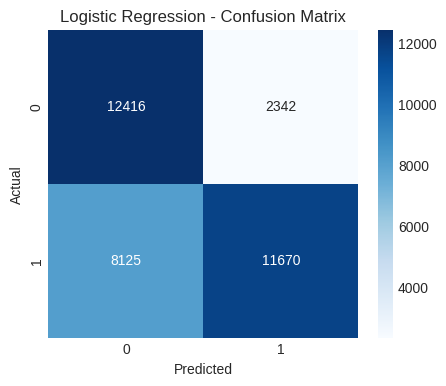


Decision Tree
Accuracy: 0.812
Precision: 0.838
Recall: 0.832
F1: 0.835
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     14758
           1       0.84      0.83      0.84     19795

    accuracy                           0.81     34553
   macro avg       0.81      0.81      0.81     34553
weighted avg       0.81      0.81      0.81     34553



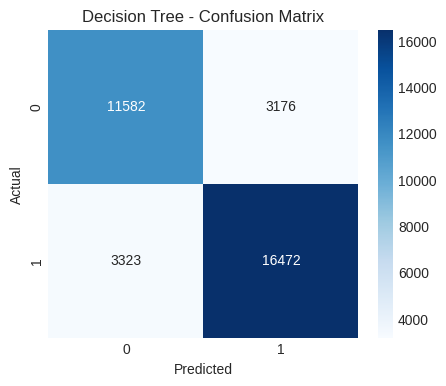


Random Forest
Accuracy: 0.79
Precision: 0.838
Recall: 0.784
F1: 0.811
              precision    recall  f1-score   support

           0       0.73      0.80      0.76     14758
           1       0.84      0.78      0.81     19795

    accuracy                           0.79     34553
   macro avg       0.79      0.79      0.79     34553
weighted avg       0.79      0.79      0.79     34553



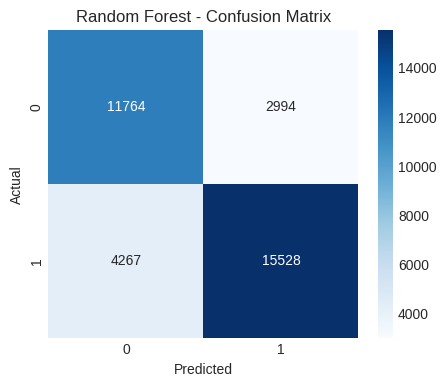

In [57]:
for name, model in models.items():


    if name == "Logistic Regression":

        evaluate_model(
            name,
            model,
            X_train_scaled,
            X_test_scaled
        )

    else:

        evaluate_model(
            name,
            model,
            X_train_bal,
            X_test
        )

In [58]:
comparison = pd.DataFrame(
    results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
).T


comparison.round(3)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.697,0.833,0.590,0.690,0.709
Decision Tree,0.812,0.838,0.832,0.835,0.811
Random Forest,0.790,0.838,0.784,0.811,0.880


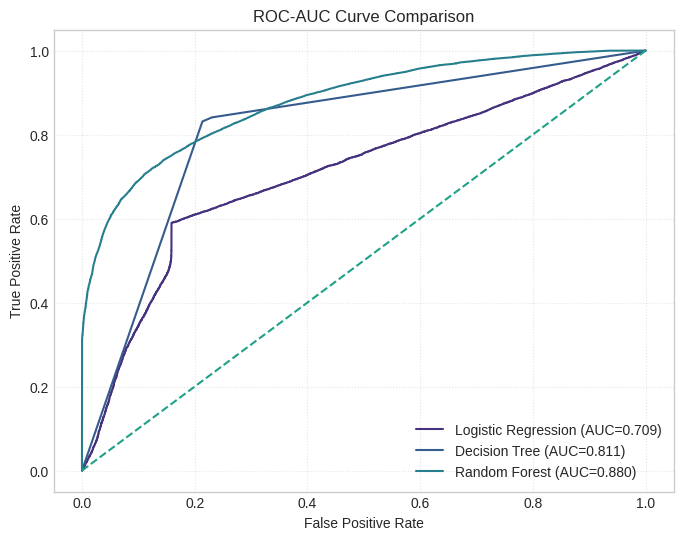

In [59]:
# ===========================
# ROC CURVE
# ===========================


plt.figure(figsize=(8,6))


for name,(y_true,y_prob) in roc_results.items():

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )


plt.plot(
    [0,1],
    [0,1],
    '--'
)


plt.title(
    "ROC-AUC Curve Comparison"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.legend()

plt.grid(
    linestyle=':',
    alpha=0.5
)

plt.show()